In [47]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from scipy.stats import wilcoxon
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, f1_score, \
    balanced_accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

from CustomSpeachDataset import CustomSpeachDataset
from Ensemble import Ensemble

In [48]:
plt.style.use("default")

In [49]:
device = device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [50]:
MODELS_DIR = Path("checkpoints")

In [51]:
dataset = CustomSpeachDataset(Path("preprocessed_dataset"), preload=False, device=device)

In [52]:
pd.DataFrame(dataset.LABEL_NAMES, columns=["label"])

,label
0,dog
1,cat
2,bird
3,stop
4,wow
5,up
6,down
7,go
8,happy
9,zero


In [53]:
_, test_indices = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    stratify=dataset.y.cpu(),
    random_state=42
)

test_dataset = torch.utils.data.Subset(dataset, test_indices)
test_loader = DataLoader(test_dataset, batch_size=1024)

In [54]:
dirs_to_compare = [
    MODELS_DIR / "training/best_without_decay",
    MODELS_DIR / "training/best",
]

ensembles = []
y_pred = np.zeros((len(dirs_to_compare), len(test_dataset)))
y_pred.shape

(2, 3670)

{'lr': 0.001, 'dropout_rate': 0.15, 'weight_decay': 0.0}
f1_score_weighted=0.8991
balanced_accuracy=0.9008


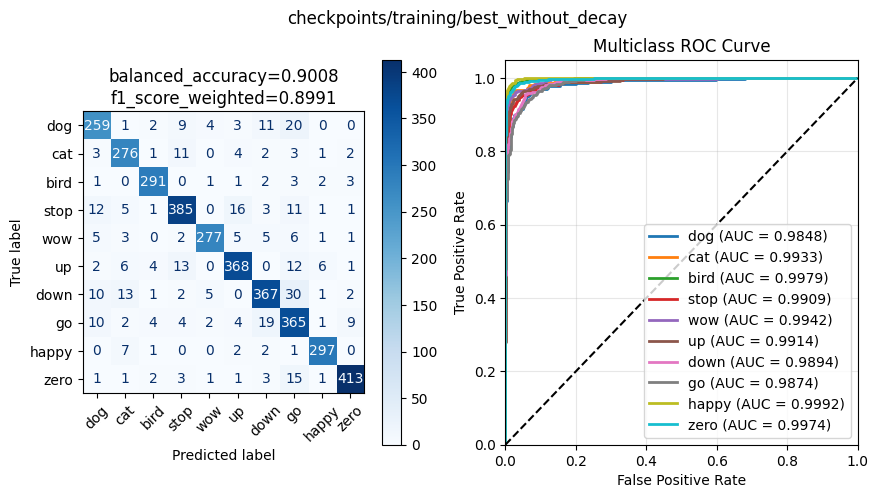

{'lr': 0.001, 'dropout_rate': 0.15, 'weight_decay': 0.0006}
f1_score_weighted=0.9194
balanced_accuracy=0.9216


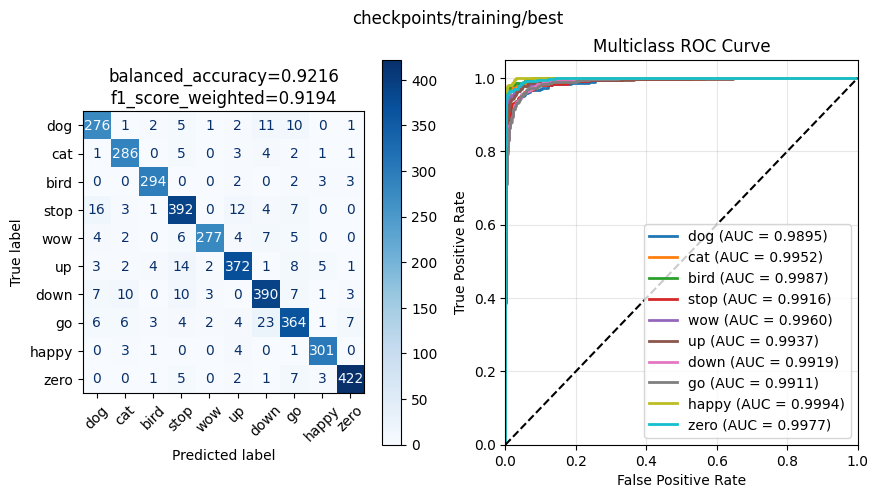

In [55]:
for ens_idx, models_dir in enumerate(dirs_to_compare):
    ensemble = Ensemble(models_dir)
    ensemble.eval()
    ensemble.to(device)
    ensembles.append(ensemble)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    fig.suptitle(str(models_dir))

    probs_batches = []
    y_test_batches = []
    with torch.no_grad():
        for X, y in test_loader:
            y_pred_step = ensemble(X).cpu()
            probs_batches.append(y_pred_step)
            y_test_batches.append(y)

    probs = np.concatenate(probs_batches)
    y_test = np.concatenate(y_test_batches)
    y_pred[ens_idx] = np.argmax(probs, axis=1)

    balanced_accuracy = balanced_accuracy_score(y_test, y_pred[ens_idx])
    f1_score_weighted = f1_score(y_test, y_pred[ens_idx], average='weighted')

    print(ensemble.model_params)
    print(f"{f1_score_weighted=:.4f}")
    print(f"{balanced_accuracy=:.4f}")

    classes = dataset.LABEL_NAMES

    ax = axs[0]
    cm = confusion_matrix(y_test, y_pred[ens_idx])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
    ax.set_title(f"{balanced_accuracy=:.4f}\n{f1_score_weighted=:.4f}")

    ax = axs[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = len(dataset.LABEL_NAMES)

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test == i, probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown",
              "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

    for i, color in zip(range(n_classes), colors):
        ax.plot(
            fpr[i],
            tpr[i],
            color=color,
            lw=2,
            label=f'{dataset.LABEL_NAMES[i]} (AUC = {roc_auc[i]:.4f})'
        )

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    plt.show()

ensembles = torch.nn.ModuleList(ensembles)

In [56]:
f1_for_ensembles = []
for ens_idx, models_dir in enumerate(dirs_to_compare):
    f1_ovr = f1_score(y_test, y_pred[ens_idx], average=None)
    f1_for_ensembles.append(f1_ovr)

winners = []
for i in range(len(classes)):
    f1_for_this_class = [f1_scores[i] for f1_scores in f1_for_ensembles]
    winner_idx = np.argmax([f1_for_this_class])
    winner = dirs_to_compare[winner_idx].name
    winners.append(winner)

pd.DataFrame({
    "label": dataset.LABEL_NAMES,
    **{dirs_to_compare[ens_idx].name: f1_ovr for ens_idx, f1_ovr in enumerate(f1_for_ensembles)},
    "winner": winners,
})

,label,best_without_decay,best,winner
0,dog,0.846405,0.887460,best
1,cat,0.894652,0.928571,best
2,bird,0.952537,0.963934,best
3,stop,0.891204,0.894977,best
4,wow,0.931092,0.938983,best
5,up,0.901961,0.910649,best
6,down,0.868639,0.894495,best
7,go,0.823928,0.873950,best
8,happy,0.956522,0.963200,best
9,zero,0.946163,0.960182,best


In [57]:
_, p_val = wilcoxon(f1_for_ensembles[0], f1_for_ensembles[1])
print(f"p={p_val:.4f}")

p=0.0020
